In [33]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Rutas confirmadas
data_path = '/kaggle/input/datasets/anjosut/galaxy-zoo-classification/Train_images/Train_images'

# Parámetros
IMG_SIZE = (224, 224)
BATCH_SIZE = 64 # Aprovechando las 2 GPUs subimos el batch

# Generador con Aumento de Datos (Data Augmentation)
# Esto ayuda a que el modelo no se memorice las fotos
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=360,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 23037 images belonging to 5 classes.
Found 5756 images belonging to 5 classes.


In [34]:
# Usamos una estrategia de distribución para usar las DOS GPUs T4
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Base de MobileNetV2: ligera y potente
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False # Congelamos el conocimiento previo

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(5, activation='softmax') # Tus 5 categorías
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

# ¡A entrenar!
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1776223465.527507     290 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776223465.528002     289 cuda_dnn.cc:529] Loaded cuDNN version 91002


360/360 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5926 - loss: 0.9573INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
360/360 ━━━━━━━━━━━━━━━━━━━━ 484s 1s/step - accuracy: 0.5928 - loss: 0.9569 - val_accuracy: 0.7187 - val_loss: 0.6535 - learning_rate: 0.0010
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.6870 - loss: 0.6920 - val_accuracy: 0.7274 - val_loss: 0.6187 - learning_rate: 0.0010
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 410s 1s/step - accuracy: 0.7041 - loss: 0.6644 - val_accuracy: 0.7198 - val_loss: 0.6359 - learning_rate: 0.0010
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 409s 1s/step - accuracy: 0.7091 - loss: 0.6431 - val_accuracy: 0.7191 - val_loss: 0.6158 - learning_rate: 0.0010
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 408s 1

In [36]:
model.save('clasificador_galaxias_final.h5')
print("Archivo 'clasificador_galaxias_final.h5' guardado con éxito.")

Archivo 'clasificador_galaxias_final.h5' guardado con éxito.


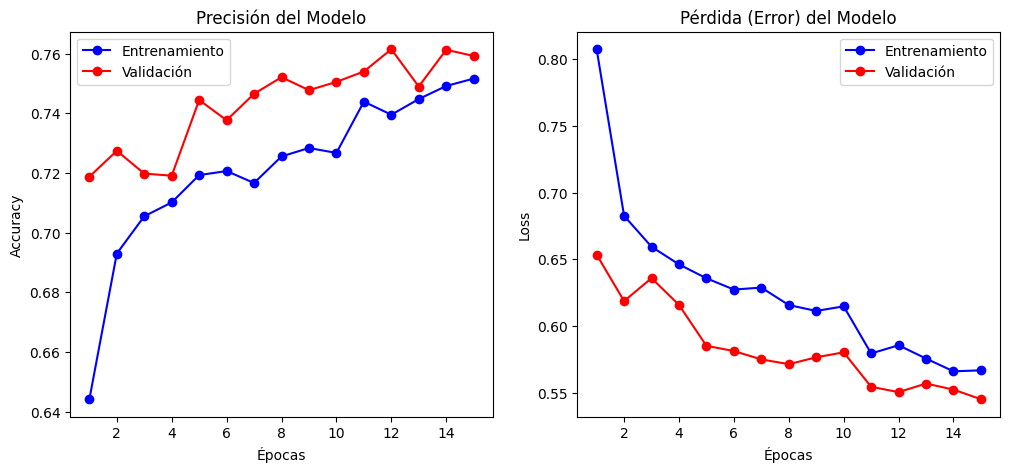

In [37]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    
    # Gráfica de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
    plt.plot(epochs, val_acc, 'ro-', label='Validación')
    plt.title('Precisión del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    # Gráfica de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'ro-', label='Validación')
    plt.title('Pérdida (Error) del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

90/90 ━━━━━━━━━━━━━━━━━━━━ 84s 898ms/step


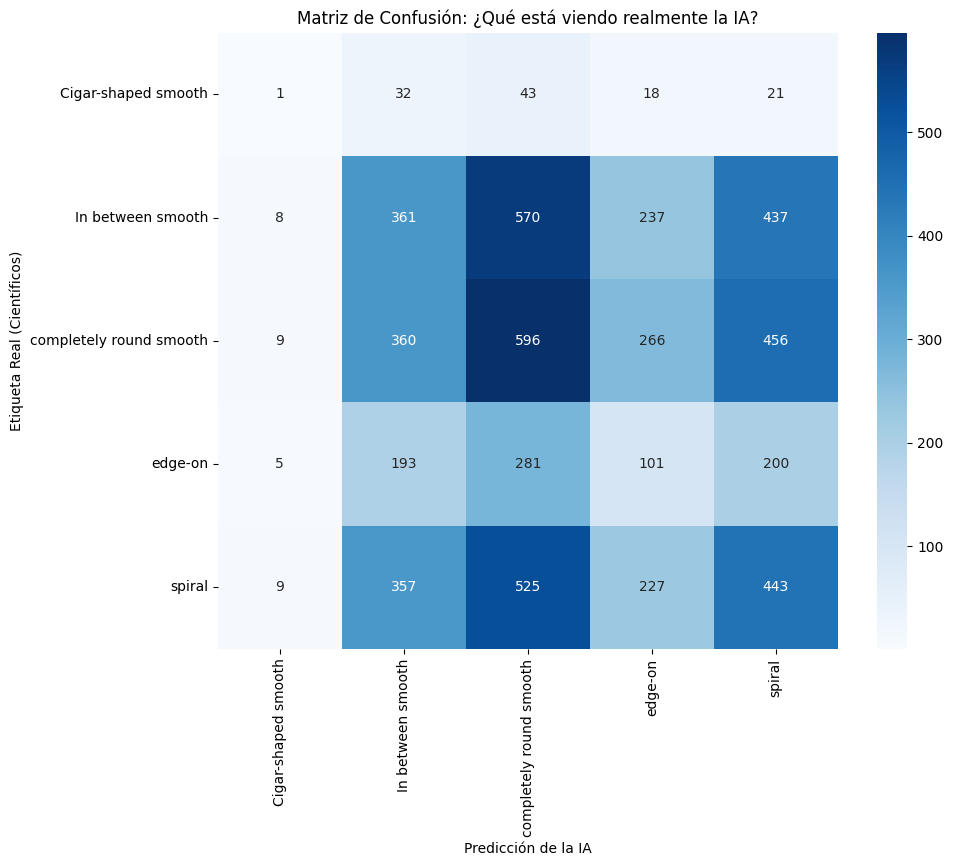

In [38]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtener predicciones
val_generator.reset()
y_true = val_generator.classes
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# 2. Configurar la matriz
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Dibujar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Matriz de Confusión: ¿Qué está viendo realmente la IA?')
plt.xlabel('Predicción de la IA')
plt.ylabel('Etiqueta Real (Científicos)')
plt.show()

=== REPORTE DE CLASIFICACIÓN MORFOLÓGICA (AGRUPADO) ===
                    precision    recall  f1-score   support

   ELÍPTICA/SMOOTH       0.59      0.58      0.59      3415
           ESPIRAL       0.28      0.28      0.28      1561
LENTICULAR/EDGE-ON       0.12      0.13      0.12       780

          accuracy                           0.44      5756
         macro avg       0.33      0.33      0.33      5756
      weighted avg       0.44      0.44      0.44      5756



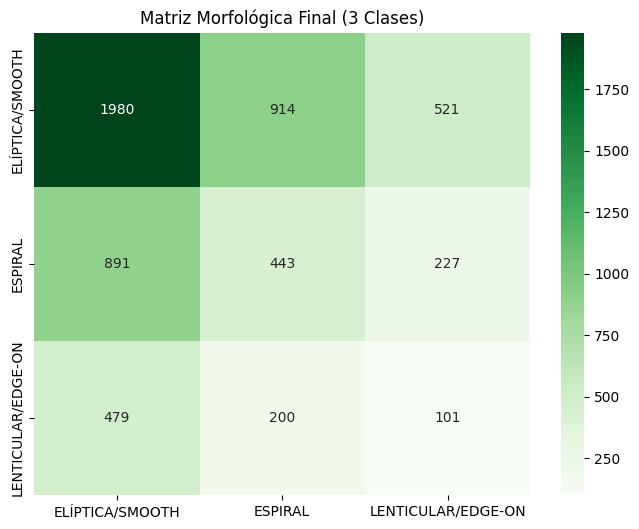

In [39]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definimos el mapeo de 5 clases a 3 categorías principales
# El orden depende de cómo las leyó tu generador (el orden alfabético de las carpetas)
mapping = {
    'Cigar-shaped smooth': 'ELÍPTICA/SMOOTH',
    'In between smooth': 'ELÍPTICA/SMOOTH',
    'completely round smooth': 'ELÍPTICA/SMOOTH',
    'edge-on': 'LENTICULAR/EDGE-ON',
    'spiral': 'ESPIRAL'
}

# 2. Obtenemos los nombres de las clases originales
original_class_names = list(val_generator.class_indices.keys())

# 3. Convertimos las etiquetas reales y predicciones a las nuevas 3 categorías
y_true_mapped = [mapping[original_class_names[i]] for i in y_true]
y_pred_mapped = [mapping[original_class_names[i]] for i in y_pred_classes]

# 4. Mostramos el nuevo reporte de éxito
print("=== REPORTE DE CLASIFICACIÓN MORFOLÓGICA (AGRUPADO) ===")
print(classification_report(y_true_mapped, y_pred_mapped))

# 5. Nueva Matriz de Confusión simplificada
new_labels = ['ELÍPTICA/SMOOTH', 'ESPIRAL', 'LENTICULAR/EDGE-ON']
cm_mapped = confusion_matrix(y_true_mapped, y_pred_mapped, labels=new_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mapped, annot=True, fmt='d', cmap='Greens', 
            xticklabels=new_labels, yticklabels=new_labels)
plt.title('Matriz Morfológica Final (3 Clases)')
plt.show()

In [40]:
from sklearn.metrics import classification_report

print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

--- REPORTE DE CLASIFICACIÓN ---
                         precision    recall  f1-score   support

    Cigar-shaped smooth       0.03      0.01      0.01       115
      In between smooth       0.28      0.22      0.25      1613
completely round smooth       0.30      0.35      0.32      1687
                edge-on       0.12      0.13      0.12       780
                 spiral       0.28      0.28      0.28      1561

               accuracy                           0.26      5756
              macro avg       0.20      0.20      0.20      5756
           weighted avg       0.26      0.26      0.26      5756



In [41]:
print(val_generator.class_indices)

{'Cigar-shaped smooth': 0, 'In between smooth': 1, 'completely round smooth': 2, 'edge-on': 3, 'spiral': 4}


=== REPORTE MORFOLÓGICO DEFINITIVO ===
                    precision    recall  f1-score   support

   ELÍPTICA/SMOOTH       0.59      0.58      0.59      3415
LENTICULAR/EDGE-ON       0.12      0.13      0.12       780
           ESPIRAL       0.28      0.28      0.28      1561

          accuracy                           0.44      5756
         macro avg       0.33      0.33      0.33      5756
      weighted avg       0.44      0.44      0.44      5756



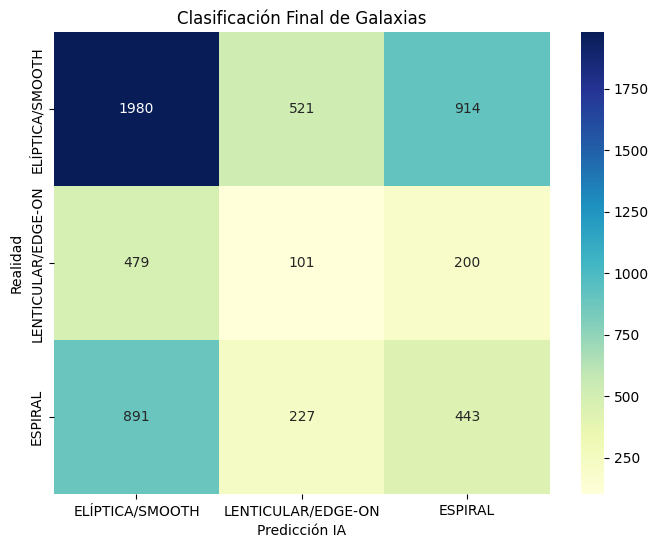

In [42]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# 1. Mapeo exacto basado en tus indices
# 0, 1, 2 -> Elípticas/Smooth
# 3 -> Lenticular/Edge-on
# 4 -> Espiral
mapping_indices = {0: 0, 1: 0, 2: 0, 3: 1, 4: 2}
nombres_agrupados = ['ELÍPTICA/SMOOTH', 'LENTICULAR/EDGE-ON', 'ESPIRAL']

# 2. Transformar etiquetas reales y predicciones
y_true_final = np.array([mapping_indices[label] for label in y_true])
y_pred_final = np.array([mapping_indices[label] for label in y_pred_classes])

# 3. Imprimir el Reporte Final
print("=== REPORTE MORFOLÓGICO DEFINITIVO ===")
print(classification_report(y_true_final, y_pred_final, target_names=nombres_agrupados))

# 4. Matriz de Confusión Final
cm_final = confusion_matrix(y_true_final, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=nombres_agrupados, yticklabels=nombres_agrupados)
plt.title('Clasificación Final de Galaxias')
plt.ylabel('Realidad')
plt.xlabel('Predicción IA')
plt.show()